In [64]:
import subprocess
from shlex import split

In [65]:
bedpe_path = "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe"

In [66]:
cmd = fr"""awk 'BEGIN{{FS=OFS="\t"}} !/^#/ {{c[$1]++; c[$4]++}}
           END{{for(chr in c) print chr, c[chr]}}' {bedpe_path} |
           sort -t$'\t' -k1,1V"""

In [67]:
subprocess.run(cmd, shell=True, check=True)

chr1	248
chr2	178
chr3	174
chr4	76
chr5	96
chr6	130
chr7	138
chr8	116
chr9	84
chr10	106
chr11	220
chr12	134
chr13	46
chr14	88
chr15	66
chr16	100
chr17	102
chr18	50
chr19	70
chr20	80
chr21	16
chr22	38
chrX	10


CompletedProcess(args='awk \'BEGIN{FS=OFS="\\t"} !/^#/ {c[$1]++; c[$4]++}\n           END{for(chr in c) print chr, c[chr]}\' /usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe |\n           sort -t$\'\\t\' -k1,1V', returncode=0)

In [68]:
awk_output = subprocess.run(cmd, shell=True, check=True, capture_output=True).stdout.decode("utf-8")
awk_output

'chr1\t248\nchr2\t178\nchr3\t174\nchr4\t76\nchr5\t96\nchr6\t130\nchr7\t138\nchr8\t116\nchr9\t84\nchr10\t106\nchr11\t220\nchr12\t134\nchr13\t46\nchr14\t88\nchr15\t66\nchr16\t100\nchr17\t102\nchr18\t50\nchr19\t70\nchr20\t80\nchr21\t16\nchr22\t38\nchrX\t10\n'

In [69]:
import pandas as pd, matplotlib.pyplot as plt
from tempfile import TemporaryFile

with TemporaryFile() as f:
    subprocess.run(cmd, shell=True, check=True, stdout=f)
    f.seek(0)
    #print(f.read().decode("utf-8"))
    df = pd.read_csv(
        f, sep=r"\s+", header=None, names=["chrom", "count"],
)

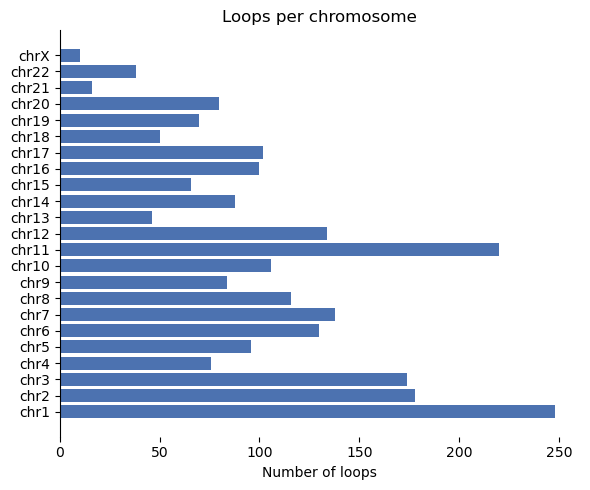

In [70]:
plt.figure(figsize=(6, 5))
bars = plt.barh(df["chrom"], df["count"], color="#4C72B0")
#for bar in bars:
#    width = bar.get_width()                                  # x-value
#    ycent = bar.get_y() + bar.get_height() / 2               # y-centre
#    plt.text(width + 40, ycent, f"{width:,}", va="center")   # 40-px offset

ax = plt.gca()                           # current axes
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)

plt.xlabel("Number of loops")
plt.title("Loops per chromosome")
plt.tight_layout()
plt.show()

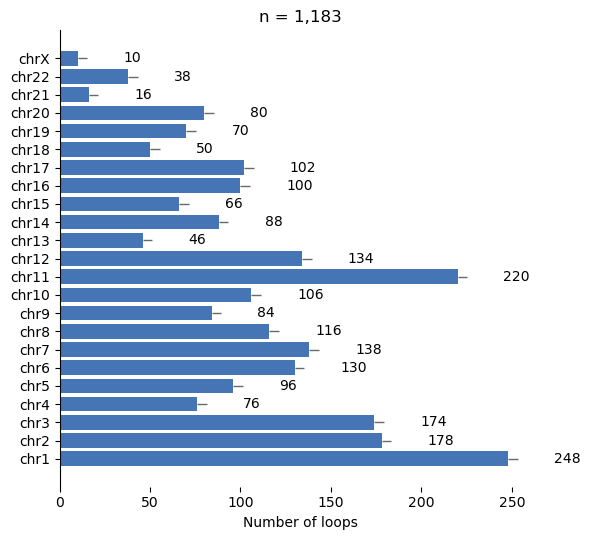

In [71]:
fig, ax = plt.subplots(figsize=(6, 5.5))
bars = ax.barh(df["chrom"], df["count"], color="#4575b4")

for bar in bars:
    w  = bar.get_width()
    yc = bar.get_y() + bar.get_height()/2

    # small line (2 % of the x-axis range)
    tick_len = 0.02 * ax.get_xlim()[1]
    ax.hlines(yc, w, w + tick_len, color="dimgray", linewidth=1)

    # label just past the tick
    ax.text(w + tick_len + 20, yc, f"{int(w):,}",
            va="center", color='black', fontsize=10)

# tidy axes
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)

ax.set_xlabel("Number of loops")
ax.set_title(f"n = {df['count'].sum()//2:,}")
#ax = plt.gca()
#ax.tick_params(axis="x", bottom=False, labelbottom=False)
#ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.show()

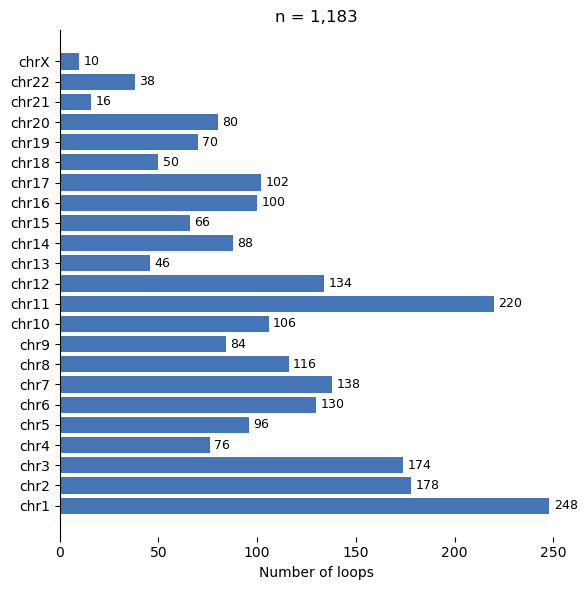

In [72]:
fig, ax = plt.subplots(figsize=(6, 6))

bars = ax.barh(df["chrom"], df["count"], color="#4575b4")

# add labels right at the bar tip, 3 pt away
ax.bar_label(
    bars,
    labels=[f"{c:,}" for c in df["count"]],
    padding=3,          # distance in points
    fontsize=9,
    color="black"
)

ax.set_xlabel("Number of loops")
ax.set_title(f"n = {df['count'].sum()//2:,}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()